Author: Catherine Gatt

Date: 24/02/2026

Content: 
Figure 2C D E, bar charts of de genes and caste specific genes 

In [1]:
print('hello')
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import scanpy as sc
from matplotlib import rc_context
from math import ceil
import scanpy as sc
import pandas as pd


h5ad_file = "/home/catherine/phd/projects/termites/data/znev/combined_no_norm_clustered.h5ad"
adata = sc.read_h5ad(h5ad_file)


hello


In [2]:
# --- imports ---
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- palette ---
palette = sns.color_palette("Set3", n_colors=4)
castes = ["queen", "king", "soldier", "worker"]
palette_dict = dict(zip(castes, palette))

# --- params ---
cell_type_col = 'paper_cell_type_annotation'
caste_col = 'caste'
alpha = 0.05
min_cells_per_group = 2
reference_caste = 'worker'

# ---------- Desired cell-type groups (3 columns) ----------
desired_orders = [[
    'female reproductive system',
    'T1',
], [
    'stem cell',
    'fat cell',
    'intestinal progenitor like',
    'cardiac cell',
], [
    'muscle cell',
    'neuron',
    'sensory neuron',
    'glial cell',
    'oenocyte',
]]

In [3]:
# ============================================================
# A–B) Load precomputed differential expression (caste vs worker)
#      and derive the summaries used in this notebook
# ============================================================

from pathlib import Path

DE_PATH = Path("derived") / "differential_expression.parquet"
differential_expression = pd.read_parquet(DE_PATH)
print("Loaded:", DE_PATH.resolve(), differential_expression.shape)

# choose p-value column the same way as the compute notebook
pcol = "pvals_adj" if differential_expression["pvals_adj"].notna().any() else "pvals"

# Keep only comparisons we need (each caste vs worker)
de_ct = differential_expression[
    (differential_expression["reference_caste"] == reference_caste) &
    (differential_expression["caste"].isin(castes))
].copy()

cell_types = list(pd.unique(adata.obs[cell_type_col]))

# ============================================================
# A) DEG counts vs worker (Row 2 data) – up and down
#     -> df_results (used by Row 2 plotting)
# ============================================================
sig = de_ct[de_ct[pcol] < alpha].copy()

counts = (
    sig.assign(
        up=(sig["logfoldchanges"] > 0).astype(int),
        down=(sig["logfoldchanges"] < 0).astype(int),
    )
    .groupby(["cell_type", "caste"], as_index=False)
    .agg(
        upregulated_genes=("up", "sum"),
        downregulated_genes=("down", "sum"),
        n_caste_cells=("n_caste_cells", "max"),
        n_rest_cells=("n_reference_cells", "max"),
    )
)

# ensure all cell_type × caste combinations exist (fill 0)
grid = pd.MultiIndex.from_product([cell_types, castes], names=["cell_type", "caste"]).to_frame(index=False)

df_results = (
    grid.merge(counts, on=["cell_type", "caste"], how="left")
        .fillna({"upregulated_genes": 0, "downregulated_genes": 0, "n_caste_cells": 0, "n_rest_cells": 0})
)

for col in ["upregulated_genes","downregulated_genes","n_caste_cells","n_rest_cells"]:
    df_results[col] = df_results[col].astype(int)

# ============================================================
# B) UNIQUE up-regulated (Row 3 data)
#     -> df_results_row3 (used by Row 3 plotting)
# ============================================================
target_castes = ["queen", "king", "soldier"]
up_only = sig[sig["logfoldchanges"] > 0].copy()

# up_sets[cell_type][caste] -> set(names)
up_sets = {}
for ct in cell_types:
    up_sets[ct] = {}
    for caste in target_castes:
        genes = up_only.loc[(up_only["cell_type"] == ct) & (up_only["caste"] == caste), "names"]
        up_sets[ct][caste] = set(genes.astype(str).tolist())

rows3 = []
for ct, d in up_sets.items():
    S = d.get("soldier", set())
    K = d.get("king", set())
    Q = d.get("queen", set())
    rows3.extend([
        {"cell_type": ct, "caste": "soldier", "upregulated_genes": len(S - (K | Q)), "downregulated_genes": 0},
        {"cell_type": ct, "caste": "king",    "upregulated_genes": len(K - (S | Q)), "downregulated_genes": 0},
        {"cell_type": ct, "caste": "queen",   "upregulated_genes": len(Q - (S | K)), "downregulated_genes": 0},
        {"cell_type": ct, "caste": "worker",  "upregulated_genes": 0,                "downregulated_genes": 0},
    ])

df_results_row3 = pd.DataFrame(rows3)


Loaded: /home/catherine/phd/projects/termites/code/znev_analysis/paper_code/fig_2/derived/differential_expression.parquet (941952, 15)


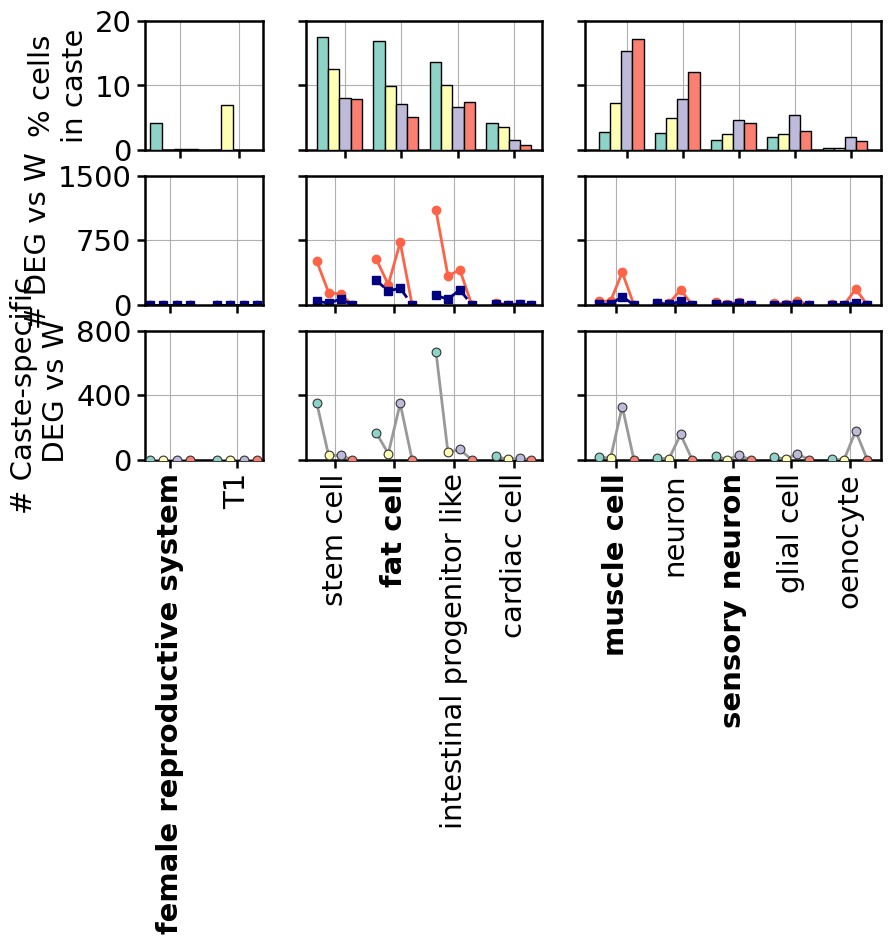

In [15]:
# ============================================================
# C) Row 1 data: % cell-type composition per caste
# FIXED: compute fractions across ALL cell types first
# ============================================================
import numpy as np
from matplotlib.ticker import MaxNLocator

data = adata.obs[[caste_col, cell_type_col]]

cell_counts_all = (
    data.groupby([caste_col, cell_type_col], observed=False)
    .size()
    .reset_index(name='count')
)

pivot_table_all = (
    cell_counts_all
    .pivot(index=cell_type_col, columns=caste_col, values='count')
    .fillna(0)
)

pivot_table_all = pivot_table_all.reindex(columns=castes, fill_value=0)

total_cells_per_caste = pivot_table_all.sum(axis=0)

fraction_table_all = pivot_table_all.divide(total_cells_per_caste, axis=1) * 100.0

cell_types_to_plot = [ct for ct in sum(desired_orders, []) if ct in fraction_table_all.index]

fraction_table = fraction_table_all.loc[cell_types_to_plot]


# ============================================================
# D) Plotting helpers
# ============================================================
def plot_deg_row(axs_row, desired_orders, df_results_like, castes,
                 *, legend_labels=False, to_bold=None, show_down=True,
                 show_xticklabels=True,
                 up_fmt='-o', up_style=dict(lw=2, color='tomato'),
                 down_fmt='--s', down_style=dict(lw=2, color='navy')):

    bar_width = 1 / (len(castes) + 1)

    to_bold_norm = {s.lower().strip() for s in to_bold} if to_bold else set()

    max_y_seen = 0

    for iax, (ax, desired_order) in enumerate(zip(axs_row, desired_orders)):

        for i, cell_type in enumerate(desired_order):

            up_vals, down_vals, x_coords = [], [], []

            for j, caste in enumerate(castes):

                match = df_results_like[
                    (df_results_like['cell_type'] == cell_type) &
                    (df_results_like['caste'] == caste)
                ]

                if not match.empty:
                    up_count = int(match['upregulated_genes'].values[0])
                    down_count = int(match['downregulated_genes'].values[0])
                else:
                    up_count, down_count = 0, 0

                x = i + (j - (len(castes) - 1) / 2) * bar_width

                x_coords.append(x)
                up_vals.append(up_count)
                down_vals.append(down_count)

                max_y_seen = max(max_y_seen, up_count, down_count)

            kwargs_up, kwargs_down = {}, {}

            if legend_labels and (iax == 2) and (i == 0):
                kwargs_up["label"] = "Upregulated"
                if show_down:
                    kwargs_down["label"] = "Downregulated"

            ax.plot(x_coords, up_vals, up_fmt, **up_style, **kwargs_up)

            if show_down:
                ax.plot(x_coords, down_vals, down_fmt, **down_style, **kwargs_down)

        ax.set_xticks(np.arange(len(desired_order)))

        if show_xticklabels:

            xticklabels = []

            for ct in desired_order:

                if len(ct) > 10:
                    ct = ct.replace(" ", "\n", 2)

                xticklabels.append(ct)

            ax.set_xticklabels(
                xticklabels,
                rotation=90,
                ha='right',
                va="center",
                rotation_mode="anchor"
            )

            for lbl in ax.get_xticklabels():
                if lbl.get_text().replace("\n", " ").lower().strip() in to_bold_norm:
                    lbl.set_fontweight("bold")

        else:
            ax.set_xticklabels([])

        ax.grid(True)

    return max_y_seen


def _nice_step(maxv, target_ticks=5):

    maxv = max(1, float(maxv))

    raw = maxv / target_ticks

    exp = int(np.floor(np.log10(raw)))

    frac = raw / (10 ** exp)

    if frac <= 1:
        nice = 1
    elif frac <= 2:
        nice = 2
    elif frac <= 5:
        nice = 5
    else:
        nice = 10

    return nice * (10 ** exp)


# ============================================================
# E) Make the 3-row figure
# ============================================================

w0, w1, w2 = [max(1, len(block)) for block in desired_orders]

fig, (axs_bar, axs_deg1, axs_deg2) = plt.subplots(
    3, 3,
    figsize=(9.5, 5.7),
    gridspec_kw=dict(width_ratios=[w0, w1, w2], height_ratios=[2, 2, 2])
)


# ============================================================
# Row 1: % cells per caste
# ============================================================

for iax, (ax, desired_order) in enumerate(zip(axs_bar, desired_orders)):

    for j, caste in enumerate(castes):

        ax.bar(
            np.arange(len(desired_order)) - 0.4 + 0.2 * j,
            fraction_table.loc[desired_order, caste],
            width=0.2,
            color=palette_dict[caste],
            zorder=10,
            edgecolor="k",
        )

    ax.set_xlabel('')
    ax.set_xticks(np.arange(len(desired_order)))
    ax.set_xticklabels([""] * len(desired_order))
    ax.grid(True)

    if iax == 0:
        ax.set_ylabel('% cells\nin caste')
    else:
        ax.set_ylabel("")
        ax.set_yticks(axs_bar[0].get_yticks())
        ax.set_yticklabels([""] * len(axs_bar[0].get_yticks()))

    ax.set_ylim(0, 20)
    ax.set_yticks([0, 10, 20])


# ============================================================
# Row 2: DEG vs worker
# ============================================================

to_bold = {"sensory neuron", "female reproductive system", "muscle cell", "fat cell"}

max_y_row2 = plot_deg_row(
    axs_deg1,
    desired_orders,
    df_results,
    castes,
    legend_labels=True,
    to_bold=to_bold,
    show_down=True,
    show_xticklabels=False,
)

step = _nice_step(max_y_row2)

upper = int(np.ceil(max_y_row2 / step) * step)

upper = max(upper, 1)

for ax in axs_deg1:

    ax.set_ylim(0, upper)

    ticks = np.linspace(0, upper, 3)

    if upper <= 10:
        ticks = np.round(ticks).astype(int)

    ax.set_yticks(ticks)


# ============================================================
# Row 3: caste-specific genes
# ============================================================

bar_width = 1 / (len(castes) + 1)

max_y_row3 = 0

for iax, (ax, desired_order) in enumerate(zip(axs_deg2, desired_orders)):

    for i, cell_type in enumerate(desired_order):

        x_coords = []
        up_vals = []

        for j, caste in enumerate(castes):

            match = df_results_row3[
                (df_results_row3['cell_type'] == cell_type) &
                (df_results_row3['caste'] == caste)
            ]

            up_count = int(match['upregulated_genes'].values[0]) if not match.empty else 0

            x = i + (j - (len(castes) - 1) / 2) * bar_width

            x_coords.append(x)
            up_vals.append(up_count)

            max_y_row3 = max(max_y_row3, up_count)

        ax.plot(x_coords, up_vals, '-', color='0.6', lw=2, zorder=4)

        for x, y, caste in zip(x_coords, up_vals, castes):

            ax.scatter(
                x,
                y,
                s=40,
                color=palette_dict[caste],
                edgecolor='0.2',
                linewidth=0.8,
                zorder=5
            )

    ax.set_xticks(np.arange(len(desired_order)))

    xticklabels = []

    for ct in desired_order:
        xticklabels.append(ct)

    ax.set_xticklabels(
        xticklabels,
        rotation=90,
        ha='right',
        va="center",
        rotation_mode="anchor"
    )

    for lbl in ax.get_xticklabels():
        if lbl.get_text().replace("\n", " ").lower().strip() in {s.lower().strip() for s in to_bold}:
            lbl.set_fontweight("bold")

    ax.grid(True)


step3 = _nice_step(max_y_row3)

upper3 = int(np.ceil(max_y_row3 / step3) * step3)

upper3 = max(upper3, 1)

for ax in axs_deg2:

    ax.set_ylim(0, upper3)

    ticks3 = np.linspace(0, upper3, 3)

    if upper3 <= 10:
        ticks3 = np.round(ticks3).astype(int)

    ax.set_yticks(ticks3)


axs_deg1[0].set_ylabel('# DEG vs W')
axs_deg2[0].set_ylabel('# Caste-specific\n DEG vs W')

for row in (axs_deg1, axs_deg2):

    for iax, ax in enumerate(row):

        if iax != 0:
            ax.set_ylabel("")
            ax.set_yticklabels([""] * len(ax.get_yticks()))


plt.rcParams.update({
    "font.size": 21,
})


# ============================================================
# Thicken axes
# ============================================================

ALL_AXES = (
    list(axs_bar.ravel()) +
    list(axs_deg1.ravel()) +
    list(axs_deg2.ravel())
)

for ax in ALL_AXES:

    for spine in ax.spines.values():
        spine.set_linewidth(1.8)

    ax.tick_params(
        axis='both',
        which='both',
        width=1.8,
        length=6
    )

plt.savefig("figure_2_celltype_abundance_DEG.png", dpi=600, bbox_inches="tight")
plt.show()

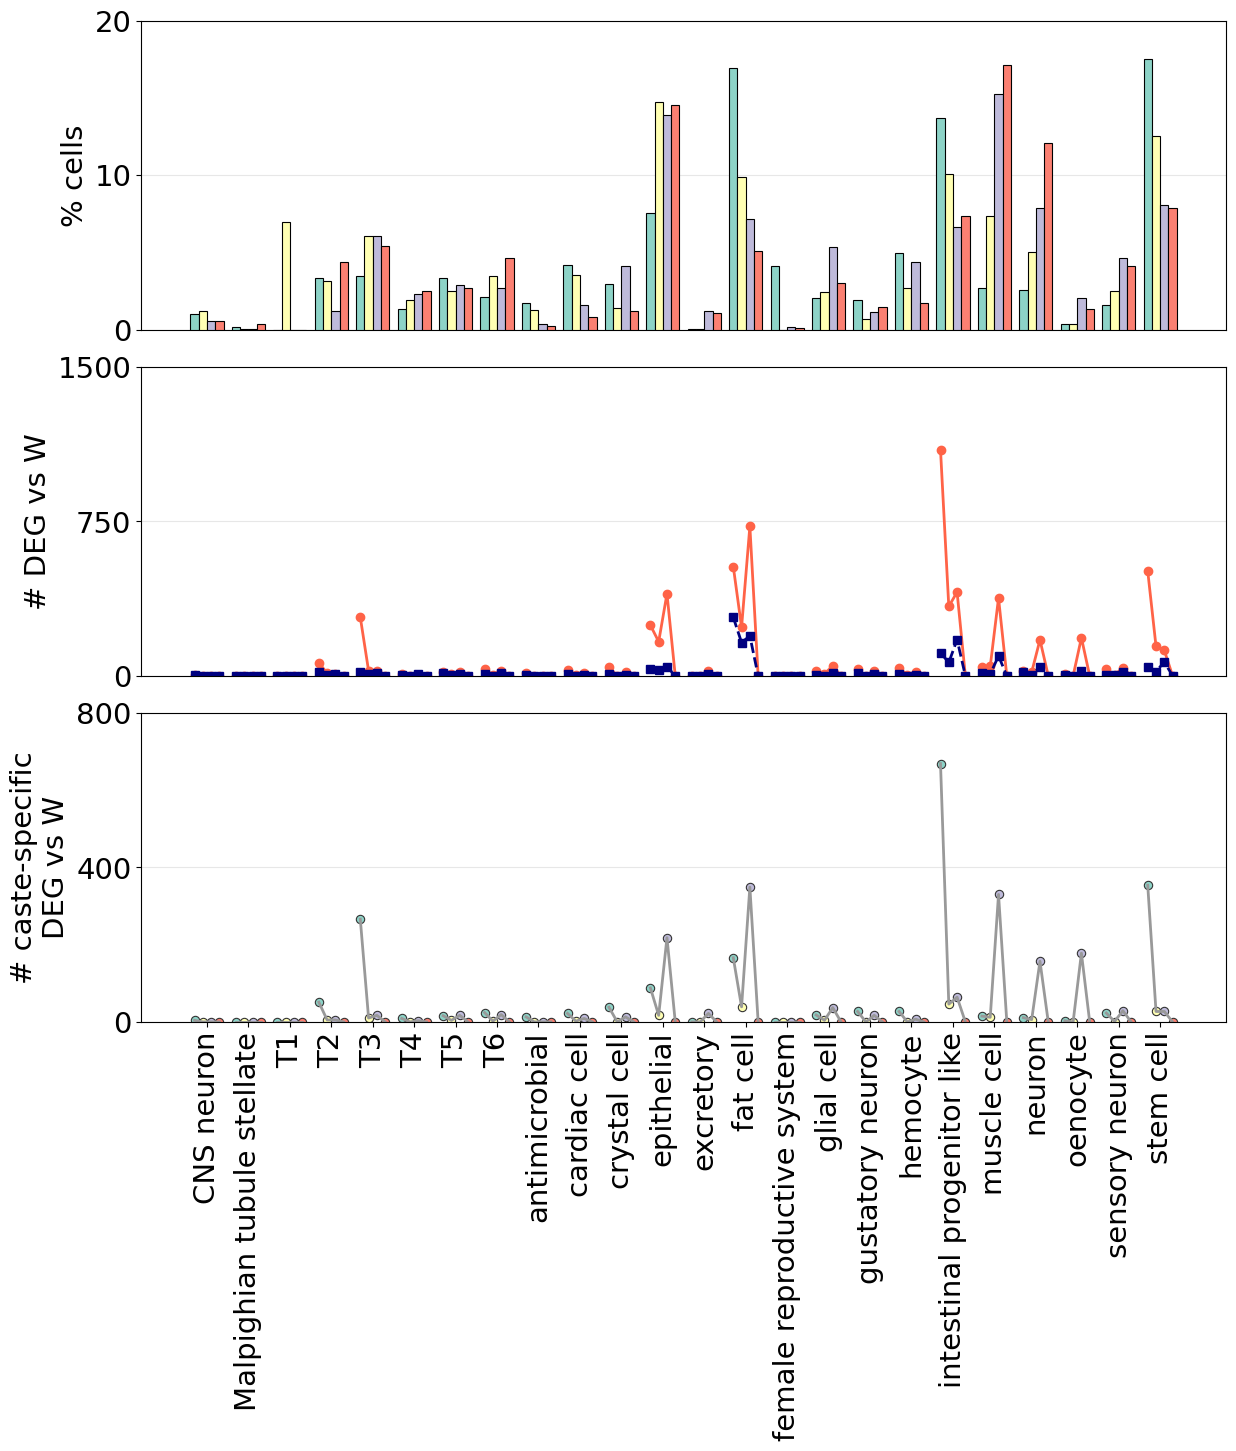

In [21]:
# ============================================================
# ALL CELL TYPES — single 3-panel plot
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1) Recompute abundance across ALL cell types in adata
# -----------------------------
cell_counts_all = (
    adata.obs
    .groupby([cell_type_col, caste_col], observed=False)
    .size()
    .reset_index(name="count")
)

fraction_table_all = (
    cell_counts_all
    .pivot(index=cell_type_col, columns=caste_col, values="count")
    .fillna(0)
)

fraction_table_all = fraction_table_all.reindex(columns=castes, fill_value=0)

fraction_table_all = fraction_table_all.divide(
    fraction_table_all.sum(axis=0), axis=1
) * 100


# -----------------------------
# 2) Collect all cell types
# -----------------------------
all_cell_types = sorted(
    set(fraction_table_all.index)
    | set(df_results["cell_type"].unique())
    | set(df_results_row3["cell_type"].unique())
)

all_cell_types = [ct for ct in all_cell_types if pd.notna(ct)]

fraction_table_all = fraction_table_all.reindex(
    index=all_cell_types,
    columns=castes
).fillna(0)


# -----------------------------
# complete DEG tables
# -----------------------------
full_index = pd.MultiIndex.from_product(
    [all_cell_types, castes],
    names=["cell_type", "caste"]
)

df_results_full = (
    df_results.set_index(["cell_type", "caste"])
    .reindex(full_index)
    .fillna(0)
    .reset_index()
)

df_results_row3_full = (
    df_results_row3.set_index(["cell_type", "caste"])
    .reindex(full_index)
    .fillna(0)
    .reset_index()
)


# -----------------------------
# helpers
# -----------------------------
def _nice_step(maxv, target_ticks=5):

    maxv = max(1, float(maxv))

    raw = maxv / target_ticks
    exp = int(np.floor(np.log10(raw)))
    frac = raw / (10 ** exp)

    if frac <= 1:
        nice = 1
    elif frac <= 2:
        nice = 2
    elif frac <= 5:
        nice = 5
    else:
        nice = 10

    return nice * (10 ** exp)


x = np.arange(len(all_cell_types))
bar_width = 1 / (len(castes) + 1)


# -----------------------------
# 3) Figure
# -----------------------------
fig, (ax_abund, ax_deg, ax_spec) = plt.subplots(
    3, 1,
    figsize=(14, 13),   # wider + slightly shorter
    sharex=True
)


# ============================================================
# PANEL 1 — abundance
# ============================================================
for j, caste in enumerate(castes):

    ax_abund.bar(
        x + (j - (len(castes)-1)/2) * bar_width,
        fraction_table_all.loc[all_cell_types, caste].values,
        width=bar_width,
        color=palette_dict[caste],
        edgecolor="k",
        linewidth=0.8,
        zorder=3
    )

ax_abund.set_ylabel("% cells")
ax_abund.grid(True, axis="y", alpha=0.3, zorder=0)
ax_abund.set_axisbelow(True)

ax_abund.set_ylim(0, 20)
ax_abund.set_yticks([0, 10, 20])


# ============================================================
# PANEL 2 — up/downregulated genes
# ============================================================
max_y_deg = 0

for i, ct in enumerate(all_cell_types):

    up_vals = []
    down_vals = []
    x_coords = []

    for j, caste in enumerate(castes):

        row = df_results_full[
            (df_results_full["cell_type"] == ct) &
            (df_results_full["caste"] == caste)
        ]

        up = float(row["upregulated_genes"].iloc[0])
        down = float(row["downregulated_genes"].iloc[0])

        xpos = i + (j - (len(castes)-1)/2) * bar_width

        x_coords.append(xpos)
        up_vals.append(up)
        down_vals.append(down)

        max_y_deg = max(max_y_deg, up, down)

    ax_deg.plot(x_coords, up_vals, "-o", lw=2, color="tomato")
    ax_deg.plot(x_coords, down_vals, "--s", lw=2, color="navy")

ax_deg.set_ylabel("# DEG vs W")
ax_deg.grid(True, axis="y", alpha=0.3, zorder=0)
ax_deg.set_axisbelow(True)

step = _nice_step(max_y_deg)
upper = np.ceil(max_y_deg / step) * step

ax_deg.set_ylim(0, upper)

ticks = np.linspace(0, upper, 3)

if upper <= 10:
    ticks = np.round(ticks).astype(int)

ax_deg.set_yticks(ticks)


# ============================================================
# PANEL 3 — caste-specific genes
# ============================================================
max_y_spec = 0

for i, ct in enumerate(all_cell_types):

    up_vals = []
    x_coords = []

    for j, caste in enumerate(castes):

        row = df_results_row3_full[
            (df_results_row3_full["cell_type"] == ct) &
            (df_results_row3_full["caste"] == caste)
        ]

        up = float(row["upregulated_genes"].iloc[0])

        xpos = i + (j - (len(castes)-1)/2) * bar_width

        x_coords.append(xpos)
        up_vals.append(up)

        max_y_spec = max(max_y_spec, up)

    ax_spec.plot(x_coords, up_vals, "-", color="0.6", lw=2)

    for xpos, y, caste in zip(x_coords, up_vals, castes):

        ax_spec.scatter(
            xpos,
            y,
            s=36,
            color=palette_dict[caste],
            edgecolor="0.2",
            linewidth=0.8
        )

ax_spec.set_ylabel("# caste-specific\nDEG vs W")
ax_spec.grid(True, axis="y", alpha=0.3, zorder=0)
ax_spec.set_axisbelow(True)

step = _nice_step(max_y_spec)
upper = np.ceil(max_y_spec / step) * step

ax_spec.set_ylim(0, upper)

ticks = np.linspace(0, upper, 3)

if upper <= 10:
    ticks = np.round(ticks).astype(int)

ax_spec.set_yticks(ticks)


# -----------------------------
# x axis
# -----------------------------
ax_spec.set_xticks(x)
ax_spec.set_xticklabels(all_cell_types, rotation=90)

for ax in (ax_abund, ax_deg):
    ax.tick_params(axis="x", length=0)

fig.subplots_adjust(hspace=0.12)

plt.savefig("figure_all_celltypes_summary.png", dpi=600, bbox_inches="tight")

plt.show()

In [9]:
# Recompute abundance table for ALL cell types from adata.obs

cell_counts_all = (
    adata.obs
    .groupby([cell_type_col, caste_col], observed=False)
    .size()
    .reset_index(name="count")
)

abundance_table_all = (
    cell_counts_all
    .pivot(index=cell_type_col, columns=caste_col, values="count")
    .fillna(0)
)

# make sure caste columns are in the order you want
abundance_table_all = abundance_table_all.reindex(columns=castes, fill_value=0)

# convert to % within each caste
abundance_table_all = abundance_table_all.divide(
    abundance_table_all.sum(axis=0), axis=1
) * 100

print("\nCell type abundance (% of cells per caste):\n")
print(abundance_table_all.round(2).to_string())
# 
#  Print abundance of each cell type in each caste




Cell type abundance (% of cells per caste):

caste                       queen   king  soldier  worker
paper_cell_type_annotation                               
epithelial                   7.60  14.73    13.92   14.52
fat cell                    16.92   9.88     7.16    5.11
stem cell                   17.52  12.54     8.05    7.88
muscle cell                  2.74   7.34    15.28   17.15
T3                           3.49   6.08     6.06    5.42
neuron                       2.57   5.03     7.87   12.12
intestinal progenitor like  13.71  10.10     6.66    7.38
T6                           2.10   3.50     2.68    4.65
sensory neuron               1.58   2.49     4.66    4.14
T2                           3.37   3.19     1.21    4.37
hemocyte                     4.95   2.71     4.41    1.76
T5                           3.35   2.49     2.93    2.72
glial cell                   2.08   2.45     5.37    3.02
crystal cell                 2.94   1.40     4.14    1.21
cardiac cell              